# Data Loading and Cleaning

The retail sales dataset is loaded using the pandas library. The dataset is checked for missing values, duplicate records, and data types to ensure data quality before analysis.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

# Descriptive Statistics

Basic statistical measures help understand the distribution of sales and customer purchasing behavior.

In [ ]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
print("Mean Sales :", df["Total Amount"].mean())

Mean Sales : 456.0


In [ ]:
print("Median Sales :", df["Total Amount"].median())

Median Sales : 135.0


In [ ]:
print("Mode Sales :")
print(df["Total Amount"].mode())

Mode Sales :
0    50
Name: Total Amount, dtype: int64


In [ ]:
print("Standard Deviation :")
print(df["Total Amount"].std())

Standard Deviation :
559.997631555123


# Time Series Analysis

Sales trends over time are analyzed to identify seasonal patterns and business performance.

In [ ]:
daily_sales = df.groupby("Date")["Total Amount"].sum()

daily_sales.head()

,Total Amount
Date,
2023-01-01,3600
2023-01-02,1765
2023-01-03,600
2023-01-04,1240
2023-01-05,1100


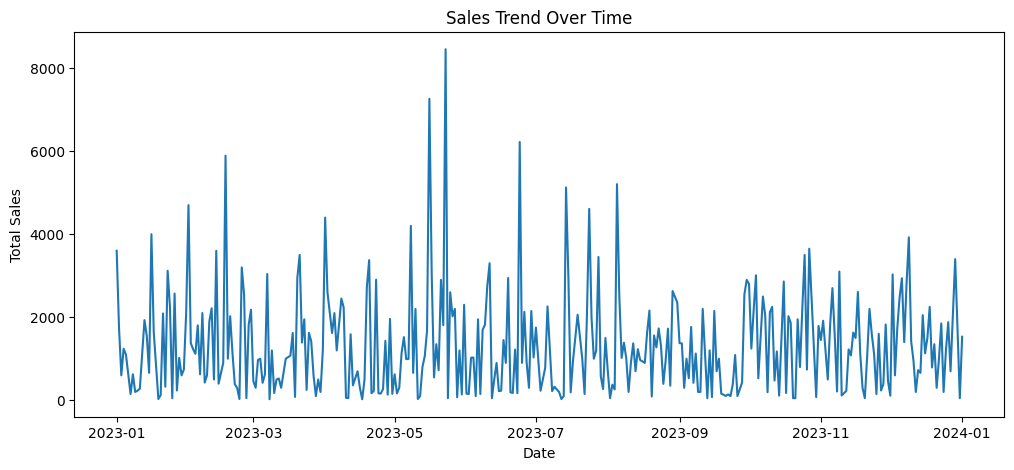

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales)

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.show()

# Customer Analysis

Customer demographics such as age and gender are analyzed to understand purchasing behavior.

In [ ]:
df["Gender"].value_counts()

,count
Gender,
Female,510
Male,490


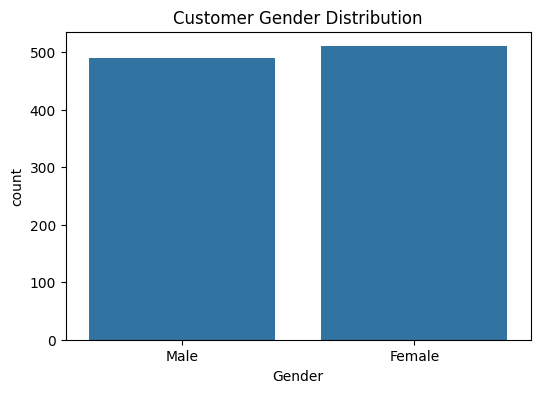

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Gender")

plt.title("Customer Gender Distribution")

plt.show()

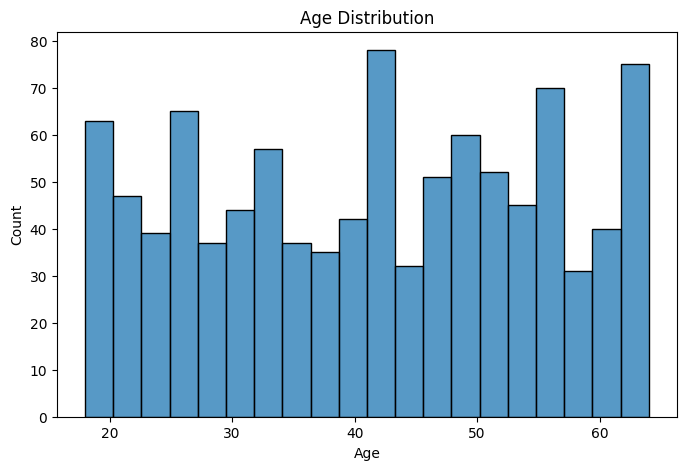

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"],bins=20)

plt.title("Age Distribution")

plt.show()

# Product Analysis

Product categories are analyzed to identify the most popular products and sales performance.

In [ ]:
df["Product Category"].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


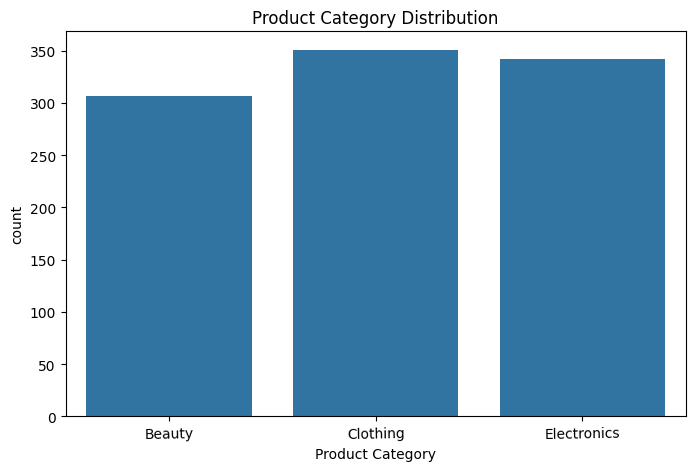

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Product Category")

plt.xticks(rotation=1)

plt.title("Product Category Distribution")

plt.show()

In [ ]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


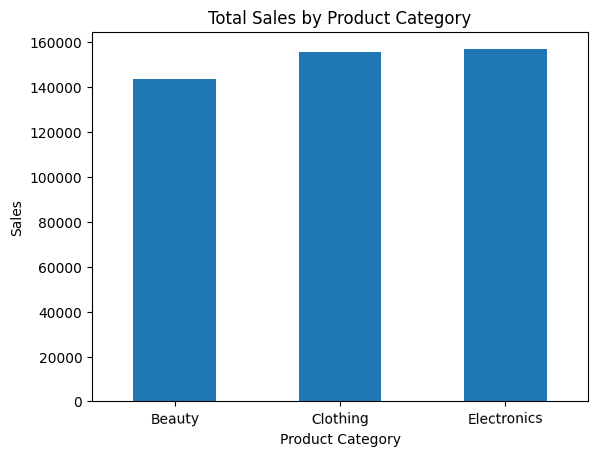

In [ ]:
category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xticks(rotation=1)
plt.ylabel("Sales")

plt.show()

## Visualization

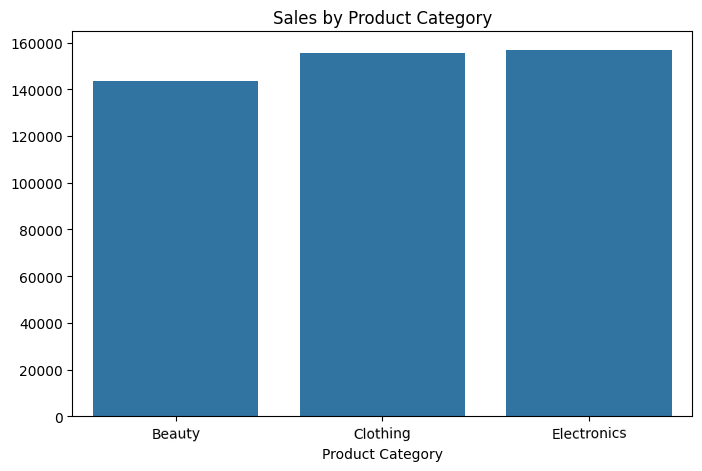

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index,y=category_sales.values)

plt.title("Sales by Product Category")

plt.xticks(rotation=1)

plt.show()

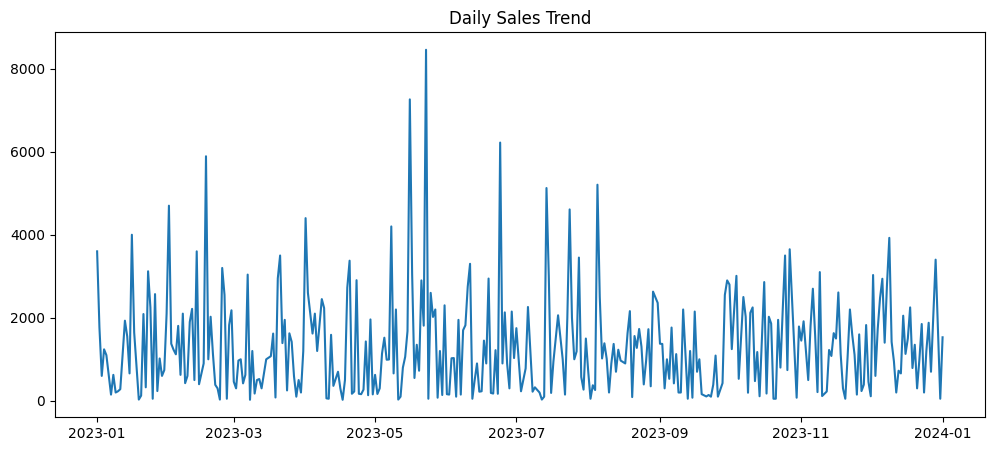

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")

plt.show()

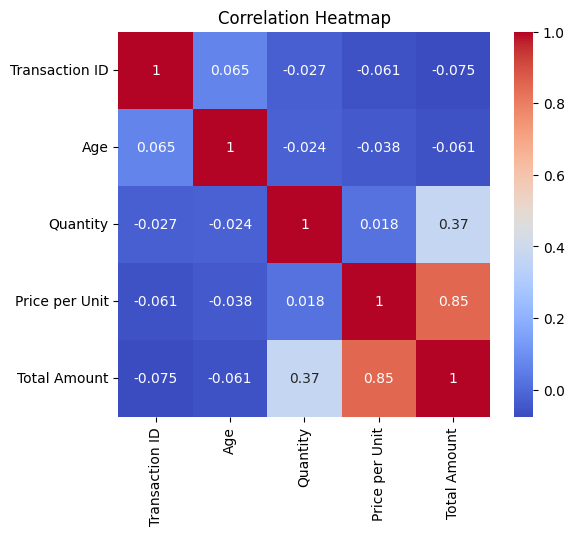

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

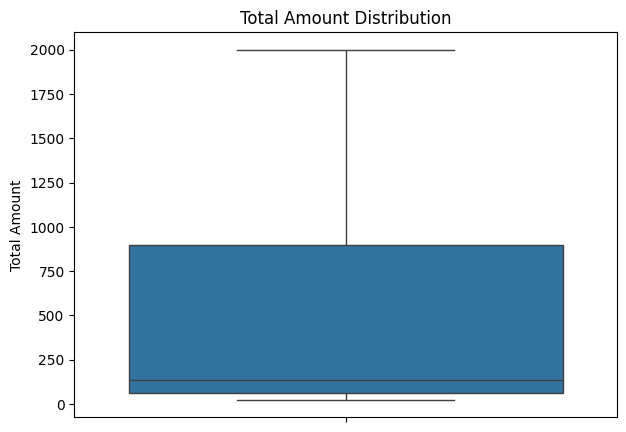

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df["Total Amount"])

plt.title("Total Amount Distribution")

plt.show()

# Recommendations

Based on the Exploratory Data Analysis (EDA), the following recommendations are suggested:

1. Focus marketing campaigns on the highest-selling product categories to maximize revenue.

2. Introduce discounts and promotional offers during low-sales periods to increase customer purchases.

3. Analyze customer age groups and gender preferences to provide personalized product recommendations.

4. Maintain sufficient inventory for products with consistently high demand to avoid stock shortages.

5. Monitor sales trends regularly using time series analysis to improve forecasting and business planning.

6. Identify low-performing products and consider improving their marketing strategy or replacing them with more popular items.

7. Implement customer loyalty programs to encourage repeat purchases and increase customer retention.

8. Use data-driven decision-making to optimize pricing strategies and promotional activities.

9. Continuously clean and update the dataset to ensure accurate analysis and reliable business insights.

10. Perform regular exploratory data analysis to identify new trends and changing customer preferences.